# Experiment Sandbox — Ferry Arrival Delay
### A separate space for controlled experiments (does NOT modify `Ferry_Delay_Regression.ipynb`)

**Why this file exists:** `Ferry_Delay_Regression.ipynb` is the finished, presentable
pipeline — it stays as-is. This notebook is a sandbox for running additional,
controlled experiments (different feature sets, splits, models, seeds) without
touching that file.

**What this notebook does, top to bottom:**
1. Loads and cleans the data exactly the same way as the original pipeline
   (same source CSV, same cleaning/winsorising/leakage-safe splits — copied, not
   imported, so this file has no dependency on the original notebook).
2. Defines an **experiment tracker**: one function, `run_experiment(...)`, that
   trains one model on one feature set under one split type and one seed, times
   training and prediction separately, computes MAE/RMSE/R², and **appends** one
   row to `experiment_results.csv`.
3. Runs one tiny smoke-test experiment to prove the tracker works end to end.

**The contract every experiment respects:**
- Results are always **appended**, never overwritten — `experiment_results.csv`
  keeps growing across runs and across kernel restarts.
- Every row has exactly these columns: `experiment_name, feature_set, split_type,
  model, MAE, RMSE, R2, training_time, prediction_time, random_seed`.
- No cell in this notebook edits `Ferry_Delay_Regression.ipynb`, its `results/main_pipeline/`
  folder, or `results/ablation/`.

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

DATA_PATH = "../data/Data-Sydney 1.csv"   # same source file as the original pipeline
TARGET = "arrival_delay"
WINSOR_LOW, WINSOR_HIGH = -206, 508
RANDOM_STATE = 42
RUN_TABPFN = True
TABPFN_MAX_CONTEXT = 10000

EXPERIMENT_RESULTS_CSV = "../results/experiments/experiment_results.csv"
RESULT_COLUMNS = ["experiment_name", "feature_set", "split_type", "model",
                   "MAE", "RMSE", "R2", "training_time", "prediction_time", "random_seed"]

print("Libraries loaded. Results will be appended to:", os.path.abspath(EXPERIMENT_RESULTS_CSV))

Libraries loaded. Results will be appended to: C:\arrival_delay\experiment_results.csv


## Step 1 — Load and clean the data
Identical logic to `Ferry_Delay_Regression.ipynb` Steps 2–5: parse weather units,
build time features, add missing-value indicators (not imputation), de-duplicate
the ~2x weather join, winsorise the target, drop the cheat columns. Copied here
verbatim rather than imported, so this sandbox has no runtime dependency on the
original notebook.

In [2]:
def extract_number(series):
    return pd.to_numeric(series.astype(str).str.extract(r"(-?\d+\.?\d*)")[0], errors="coerce")

def start_time_to_minutes(series):
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float) * 1440.0
    return pd.to_timedelta(series.astype(str), errors="coerce").dt.total_seconds() / 60.0

def parse_date(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_datetime(series, origin="1899-12-30", unit="D", errors="coerce")
    return pd.to_datetime(series, errors="coerce")

df_raw = pd.read_csv(DATA_PATH, index_col=0)
df_raw.columns = [c.strip() for c in df_raw.columns]

event_keys = ["trip_id", "start_date", "current_stop_sequence", "stop_id"]
df = df_raw.copy()

for col in ["Dew Point", "Wind Speed", "Pressure", "Humidity"]:
    if col in df.columns:
        df[col] = extract_number(df[col])

df["start_time"] = start_time_to_minutes(df["start_time"])
dt = parse_date(df["start_date"])
df["start_date_ordinal"] = (dt - dt.min()).dt.days
df["month"] = dt.dt.month
df["day_of_year"] = dt.dt.dayofyear

for col in ["stop_id", "Wind", "Condition"]:
    if col in df.columns:
        df[f"{col}_missing"] = df[col].isna().astype(int)

weather_num = ["Dew Point", "Humidity", "Wind Speed", "Pressure"]
agg = {c: ("mean" if c in weather_num else "first") for c in df.columns if c not in event_keys}
before = len(df)
df = df.groupby(event_keys, dropna=False, as_index=False).agg(agg)
print(f"Deduplicated {before:,} -> {len(df):,} unique ferry events.")

df[TARGET] = df[TARGET].clip(WINSOR_LOW, WINSOR_HIGH)
for col in ["Wind", "Condition"]:
    if col in df.columns:
        df[col] = df[col].astype("object").fillna("Missing")

DROP_COLS = ["Vessels", "vehicle_label", "Precip.", "Wind Gust", "Hour", "Total Capacity", "Ridership"]
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
df["stop_id"] = df["stop_id"].astype("object")

CATEGORICAL = [c for c in ["route_id", "stop_id", "vehicle_id", "Wind", "Condition", "Class"] if c in df.columns]
NUMERIC = [c for c in ["start_time", "start_date_ordinal", "month", "day_of_year",
           "current_stop_sequence", "Week", "Dew Point", "Humidity", "Wind Speed",
           "Pressure", "Seating Capacity", "Holidays"] if c in df.columns]
MISSING_FLAGS = [c for c in df.columns if c.endswith("_missing")]

y = df[TARGET].astype(float).values
trip_groups = df["trip_id"].values
route_groups = df["route_id"].values

print(f"Cleaned dataset: {len(df):,} rows. "
      f"{len(CATEGORICAL)} categorical + {len(NUMERIC)} numeric + {len(MISSING_FLAGS)} missing-flags.")

Deduplicated 1,048,575 -> 496,042 unique ferry events.


Cleaned dataset: 496,042 rows. 6 categorical + 12 numeric + 3 missing-flags.


## Step 2 — Named feature sets
Register feature sets by name once here; every experiment below just refers to a
name (e.g. `"all_features"`), so adding a new feature set later never requires
touching the experiment-running code.

In [3]:
FEATURE_SETS = {
    "all_features": {
        "categorical": list(CATEGORICAL),
        "numeric": list(NUMERIC),
        "missing": list(MISSING_FLAGS),
    },
    "no_route_stop": {
        "categorical": [c for c in CATEGORICAL if c not in ("route_id", "stop_id")],
        "numeric": list(NUMERIC),
        "missing": [c for c in MISSING_FLAGS if c != "stop_id_missing"],
    },
    "no_identity": {
        "categorical": [c for c in CATEGORICAL if c not in ("route_id", "stop_id", "vehicle_id")],
        "numeric": list(NUMERIC),
        "missing": [c for c in MISSING_FLAGS if c != "stop_id_missing"],
    },
}
for name, cfg in FEATURE_SETS.items():
    cfg["features"] = cfg["categorical"] + cfg["numeric"] + cfg["missing"]
    print(f"{name:14s} -> {len(cfg['features']):2d} features")

all_features   -> 21 features
no_route_stop  -> 18 features
no_identity    -> 17 features


## Step 3 — Models and encoder
Same matched-defaults philosophy as the original pipeline: XGBoost/LightGBM are
not tuned, and TabPFN is capped at its hosted-API context limit via the same
subsampling wrapper.

In [4]:
def make_encoder(cat_cols):
    return ColumnTransformer(
        [("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols)],
        remainder="passthrough")

class CapAtContext:
    def __init__(self, est, seed): self.est, self.seed, self.was_capped = est, seed, False
    def fit(self, X, y):
        if len(X) > TABPFN_MAX_CONTEXT:
            self.was_capped = True
            idx = np.random.RandomState(self.seed).choice(len(X), TABPFN_MAX_CONTEXT, replace=False)
            X, y = (X.iloc[idx] if hasattr(X, "iloc") else X[idx]), y[idx]
        self.est.fit(X, y); return self
    def predict(self, X): return self.est.predict(X)

def make_tabpfn(seed):
    from tabpfn_client import TabPFNRegressor
    return CapAtContext(TabPFNRegressor(), seed)

def make_models(seed):
    models = {
        "XGBoost":  XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6,
                       subsample=0.9, colsample_bytree=0.9, random_state=seed,
                       n_jobs=-1, tree_method="hist"),
        "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.1, num_leaves=31,
                       subsample=0.9, colsample_bytree=0.9, random_state=seed,
                       n_jobs=-1, verbose=-1),
    }
    if RUN_TABPFN:
        models["TabPFN"] = make_tabpfn(seed)
    return models

def score(y_true, y_pred):
    return {"RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "MAE":  float(mean_absolute_error(y_true, y_pred)),
            "R2":   float(r2_score(y_true, y_pred))}

print("Models + encoder ready.")

Models + encoder ready.


## Step 4 — The experiment tracker
This is the core deliverable: `run_experiment(...)` runs exactly one
(feature set x split type x model x seed) combination and **appends** one row to
`experiment_results.csv`. It never overwrites the file — if it doesn't exist yet,
it's created with a header; every call after that just appends.

**Split types supported:**
- `"trip_grouped"` — `GroupShuffleSplit` on `trip_id` (the honest default)
- `"route_grouped"` — `GroupShuffleSplit` on `route_id` (the leakage stress test)
- `"random"` — plain row-level `train_test_split` (the leaky baseline)

Training time and prediction time are measured separately with
`time.perf_counter()`, in seconds.

In [5]:
def _get_split_indices(split_type, X_full, y_full, seed):
    if split_type == "trip_grouped":
        return next(GroupShuffleSplit(n_splits=1, test_size=0.2,
                    random_state=seed).split(X_full, y_full, trip_groups))
    elif split_type == "route_grouped":
        return next(GroupShuffleSplit(n_splits=1, test_size=0.2,
                    random_state=seed).split(X_full, y_full, route_groups))
    elif split_type == "random":
        idx = np.arange(len(X_full))
        return train_test_split(idx, test_size=0.2, random_state=seed, shuffle=True)
    else:
        raise ValueError(f"Unknown split_type: {split_type!r}")


def log_experiment_result(row: dict):
    """Append one experiment result row to EXPERIMENT_RESULTS_CSV.
    Creates the file with a header on first call; every call after that appends
    without rewriting anything already on disk."""
    row = {c: row.get(c) for c in RESULT_COLUMNS}
    file_exists = os.path.isfile(EXPERIMENT_RESULTS_CSV)
    pd.DataFrame([row], columns=RESULT_COLUMNS).to_csv(
        EXPERIMENT_RESULTS_CSV, mode="a", header=not file_exists, index=False)
    return row


def run_experiment(experiment_name, feature_set, split_type, model_names=None, seed=RANDOM_STATE):
    """Train + evaluate one or more models on one feature set under one split
    type and one seed. Appends one row per model to experiment_results.csv and
    returns the list of logged rows (also printed)."""
    cfg = FEATURE_SETS[feature_set]
    Xfs = df[cfg["features"]].copy()
    tr_idx, te_idx = _get_split_indices(split_type, Xfs, y, seed)
    Xtr, Xte, ytr, yte = Xfs.iloc[tr_idx], Xfs.iloc[te_idx], y[tr_idx], y[te_idx]

    all_models = make_models(seed)
    if model_names is not None:
        all_models = {k: v for k, v in all_models.items() if k in model_names}

    logged = []
    for mname, model in all_models.items():
        enc = make_encoder(cfg["categorical"])
        t0 = time.perf_counter()
        Xtr_e = enc.fit_transform(Xtr)
        model.fit(Xtr_e, ytr)
        train_t = time.perf_counter() - t0

        t0 = time.perf_counter()
        yhat = model.predict(enc.transform(Xte))
        pred_t = time.perf_counter() - t0

        m = score(yte, yhat)
        row = {
            "experiment_name": experiment_name, "feature_set": feature_set,
            "split_type": split_type, "model": mname,
            "MAE": m["MAE"], "RMSE": m["RMSE"], "R2": m["R2"],
            "training_time": train_t, "prediction_time": pred_t, "random_seed": seed,
        }
        logged.append(log_experiment_result(row))
        print(f"[{experiment_name}] {feature_set:14s} {split_type:13s} {mname:9s} seed={seed}  "
              f"RMSE={m['RMSE']:7.1f}  MAE={m['MAE']:6.1f}  R2={m['R2']:6.3f}  "
              f"train={train_t:5.2f}s  predict={pred_t:5.2f}s")
    return logged

print("Experiment tracker ready: run_experiment(experiment_name, feature_set, split_type, model_names=None, seed=RANDOM_STATE)")

Experiment tracker ready: run_experiment(experiment_name, feature_set, split_type, model_names=None, seed=RANDOM_STATE)


### Step 4b — Resumable runs

`run_pending` wraps `run_experiment` so an experiment can be stopped and
restarted safely:

- a (experiment, feature set, split, model, seed) combination that is already
  in `experiment_results.csv` is **skipped** — nothing is trained and no TabPFN
  API call is made;
- if the TabPFN hosted API reports that the quota is exhausted (HTTP 429), the
  run **stops cleanly** and prints the combinations that are still missing.

In [ ]:
KEY_COLUMNS = ["experiment_name", "feature_set", "split_type", "model", "random_seed"]

def logged_keys():
    """Set of (experiment, feature_set, split_type, model, seed) already on disk."""
    if not os.path.isfile(EXPERIMENT_RESULTS_CSV):
        return set()
    done = pd.read_csv(EXPERIMENT_RESULTS_CSV, usecols=KEY_COLUMNS)
    return set(map(tuple, done[KEY_COLUMNS].itertuples(index=False, name=None)))

def _is_quota_error(exc):
    text = f"{type(exc).__name__}: {exc}".lower()
    return (getattr(exc, "status_code", None) == 429 or "429" in text
            or "quota" in text or "usage limit" in text or "too many requests" in text)

def run_pending(combos, model_names):
    """Run every (experiment_name, feature_set, split_type, seed) in `combos` for
    the models in `model_names`, skipping whatever is already logged. Stops
    cleanly on a TabPFN quota error. Returns the list of combinations still
    missing as (experiment_name, feature_set, split_type, model, seed)."""
    done = logged_keys()
    todo = [(e, f, s, m, seed) for (e, f, s, seed) in combos for m in model_names
            if (e, f, s, m, seed) not in done]
    print(f"{len(combos) * len(model_names)} combinations requested, "
          f"{len(combos) * len(model_names) - len(todo)} already logged, {len(todo)} to run.")
    remaining = list(todo)
    for (e, f, s, m, seed) in todo:
        try:
            run_experiment(e, feature_set=f, split_type=s, model_names=[m], seed=seed)
        except Exception as exc:
            if not _is_quota_error(exc):
                raise
            print(f"\nSTOPPED: TabPFN quota exhausted ({exc}).")
            break
        remaining.remove((e, f, s, m, seed))
    if remaining:
        print(f"{len(remaining)} combinations still missing:")
        for r in remaining:
            print("  ", r)
    else:
        print("Nothing left to run.")
    return remaining

print("Resumable runner ready: run_pending(combos, model_names)")

## Step 5 — Smoke test
Runs exactly one small experiment to prove the tracker works end to end: creates
(or appends to) `experiment_results.csv`, and reads it back to show the row
landed with the right columns and types.

In [6]:
run_experiment(
    experiment_name="smoke_test",
    feature_set="all_features",
    split_type="trip_grouped",
    model_names=["XGBoost", "LightGBM"],   # skip TabPFN here to keep the smoke test instant
    seed=RANDOM_STATE,
)

print("\n--- experiment_results.csv now contains ---")
pd.read_csv(EXPERIMENT_RESULTS_CSV)

[smoke_test] all_features   trip_grouped  XGBoost   seed=42  RMSE=   95.9  MAE=  69.2  R2= 0.369  train= 7.33s  predict= 0.32s


[smoke_test] all_features   trip_grouped  LightGBM  seed=42  RMSE=   96.5  MAE=  69.8  R2= 0.362  train= 3.98s  predict= 0.43s

--- experiment_results.csv now contains ---


,experiment_name,feature_set,split_type,model,MAE,RMSE,R2,training_time,prediction_time,random_seed
0,smoke_test,all_features,trip_grouped,XGBoost,69.186463,95.931450,0.369436,8.218884,0.413938,42
1,smoke_test,all_features,trip_grouped,LightGBM,69.768883,96.503058,0.361900,5.003945,0.439943,42
2,smoke_test,all_features,trip_grouped,XGBoost,69.186463,95.931450,0.369436,7.262710,0.317337,42
3,smoke_test,all_features,trip_grouped,LightGBM,69.768883,96.503058,0.361900,3.717524,0.438969,42
4,smoke_test,all_features,trip_grouped,XGBoost,69.186463,95.931450,0.369436,7.744911,0.381258,42
...,...,...,...,...,...,...,...,...,...,...
138,temporal_after,no_identity_temporal,route_grouped,LightGBM,84.609017,117.335334,-0.062029,2.809159,0.646315,45
139,temporal_after,no_identity_temporal,route_grouped,XGBoost,88.512044,117.873892,-0.018945,6.154376,0.172687,46
140,temporal_after,no_identity_temporal,route_grouped,LightGBM,87.954818,117.770908,-0.017166,3.766755,0.205596,46
141,smoke_test,all_features,trip_grouped,XGBoost,69.186463,95.931450,0.369436,7.325274,0.318898,42


---
## Ready

- `Ferry_Delay_Regression.ipynb` was not opened or modified by this notebook.
- `experiment_results.csv` is created on first append and grows with every
  subsequent `run_experiment(...)` call — nothing gets overwritten.
- Columns are exactly: `experiment_name, feature_set, split_type, model, MAE,
  RMSE, R2, training_time, prediction_time, random_seed`.
- To run a real experiment: call `run_experiment("your_experiment_name",
  feature_set="all_features"|"no_route_stop"|"no_identity",
  split_type="trip_grouped"|"route_grouped"|"random", seed=...)` in a new cell
  below. Add more feature sets to `FEATURE_SETS` in Step 2 as needed.

## Step 6 — Experiment: do stronger temporal features help Feature Sets B and C?
**Question:** Feature Sets B (`no_route_stop`) and C (`no_identity`) lose accuracy
once `route_id`/`stop_id` are removed (see the ablation study). Can better
time-of-day / day-of-week / seasonality features recover some of that, without
bringing identity features back?

**New temporal features** (all derived from columns already loaded — no new data
source, nothing about the evaluation methodology changes):
- `hour_of_day` — 0–23, from `start_time` (already in minutes since midnight)
- `day_of_week` — 0=Monday .. 6=Sunday, from the parsed date
- `weekend_flag` — 1 if Saturday/Sunday, else 0
- `morning_peak_flag` — 1 if `hour_of_day` in 7–9 (typical AM commute), else 0
- `evening_peak_flag` — 1 if `hour_of_day` in 16–18 (typical PM commute), else 0
- `month_sin`, `month_cos` — cyclical encoding of month (so December and January
  are numerically close, unlike the raw `month` number which jumps 12→1)

These are added **only** to two new feature-set variants, `no_route_stop_temporal`
(= B + temporal) and `no_identity_temporal` (= C + temporal) — feature set A and
the plain B/C are untouched, so "before" numbers are the exact same B/C already
in `FEATURE_SETS`.

**Evaluation stays identical to every other experiment in this project:**
trip-grouped = single 80/20 split (seed 42); route-grouped = averaged over 5
seeds (42–46), same as the ablation study. Only the feature list changes.

In [7]:
hour_of_day = (df["start_time"] // 60).clip(0, 23).astype(int)
dow = dt.dt.dayofweek  # 0=Monday .. 6=Sunday, `dt` was computed during cleaning above
df["hour_of_day"] = hour_of_day
df["day_of_week"] = dow
df["weekend_flag"] = dow.isin([5, 6]).astype(int)
df["morning_peak_flag"] = hour_of_day.between(7, 9).astype(int)
df["evening_peak_flag"] = hour_of_day.between(16, 18).astype(int)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

TEMPORAL_FEATURES = ["hour_of_day", "day_of_week", "weekend_flag",
                      "morning_peak_flag", "evening_peak_flag", "month_sin", "month_cos"]

FEATURE_SETS["no_route_stop_temporal"] = {
    "categorical": list(FEATURE_SETS["no_route_stop"]["categorical"]),
    "numeric": list(FEATURE_SETS["no_route_stop"]["numeric"]) + TEMPORAL_FEATURES,
    "missing": list(FEATURE_SETS["no_route_stop"]["missing"]),
}
FEATURE_SETS["no_identity_temporal"] = {
    "categorical": list(FEATURE_SETS["no_identity"]["categorical"]),
    "numeric": list(FEATURE_SETS["no_identity"]["numeric"]) + TEMPORAL_FEATURES,
    "missing": list(FEATURE_SETS["no_identity"]["missing"]),
}
for name in ["no_route_stop_temporal", "no_identity_temporal"]:
    cfg = FEATURE_SETS[name]
    cfg["features"] = cfg["categorical"] + cfg["numeric"] + cfg["missing"]
    print(f"{name:24s} -> {len(cfg['features']):2d} features "
          f"(+{len(TEMPORAL_FEATURES)} temporal)")

no_route_stop_temporal   -> 25 features (+7 temporal)
no_identity_temporal     -> 24 features (+7 temporal)


In [8]:
# BEFORE = B ("no_route_stop") and C ("no_identity") as already registered.
# AFTER  = the two _temporal variants just added above.
#
# NOTE: TabPFN's hosted-API daily quota is exhausted (resets 2026-08-24 00:00 UTC).
# XGBoost/LightGBM coverage for this experiment is already complete in
# experiment_results.csv, so this re-run is restricted to those two models to
# avoid crashing on the TabPFN call. TabPFN rows will be filled in separately
# once the quota resets.
CONFIGS_TO_RUN = [
    ("temporal_before", "no_route_stop"),
    ("temporal_before", "no_identity"),
    ("temporal_after",  "no_route_stop_temporal"),
    ("temporal_after",  "no_identity_temporal"),
]
ROUTE_SEEDS = [RANDOM_STATE + i for i in range(5)]   # same 5-seed methodology as the ablation study
TEMPORAL_MODELS = ["XGBoost", "LightGBM"]

for exp_name, feat_set in CONFIGS_TO_RUN:
    run_experiment(exp_name, feature_set=feat_set, split_type="trip_grouped",
                    model_names=TEMPORAL_MODELS, seed=RANDOM_STATE)
    for seed in ROUTE_SEEDS:
        run_experiment(exp_name, feature_set=feat_set, split_type="route_grouped",
                        model_names=TEMPORAL_MODELS, seed=seed)

print("\nAll temporal-feature experiments (XGBoost/LightGBM) logged to", EXPERIMENT_RESULTS_CSV)

[temporal_before] no_route_stop  trip_grouped  XGBoost   seed=42  RMSE=  105.0  MAE=  77.5  R2= 0.245  train= 5.42s  predict= 0.25s


[temporal_before] no_route_stop  trip_grouped  LightGBM  seed=42  RMSE=  105.0  MAE=  77.6  R2= 0.245  train= 3.32s  predict= 0.34s


[temporal_before] no_route_stop  route_grouped XGBoost   seed=42  RMSE=  122.5  MAE=  95.8  R2=-0.074  train= 5.90s  predict= 0.18s


[temporal_before] no_route_stop  route_grouped LightGBM  seed=42  RMSE=  118.1  MAE=  91.3  R2= 0.002  train= 3.55s  predict= 0.24s


[temporal_before] no_route_stop  route_grouped XGBoost   seed=43  RMSE=  144.8  MAE= 109.7  R2=-0.196  train= 5.13s  predict= 0.28s


...

[temporal_after] no_identity_temporal route_grouped LightGBM  seed=44  RMSE=  120.1  MAE=  84.6  R2=-0.120  train= 2.95s  predict= 0.67s


[temporal_after] no_identity_temporal route_grouped XGBoost   seed=45  RMSE=  120.6  MAE=  88.6  R2=-0.123  train= 3.63s  predict= 0.60s


[temporal_after] no_identity_temporal route_grouped LightGBM  seed=45  RMSE=  117.3  MAE=  84.6  R2=-0.062  train= 2.84s  predict= 0.76s


[temporal_after] no_identity_temporal route_grouped XGBoost   seed=46  RMSE=  117.9  MAE=  88.5  R2=-0.019  train= 6.23s  predict= 0.16s


[temporal_after] no_identity_temporal route_grouped LightGBM  seed=46  RMSE=  117.8  MAE=  88.0  R2=-0.017  train= 3.88s  predict= 0.21s

All temporal-feature experiments (XGBoost/LightGBM) logged to experiment_results.csv


In [ ]:
# TabPFN rows for the temporal-feature experiment: same configurations, splits
# and seeds as the XGBoost/LightGBM cell above. Already-logged rows are skipped,
# so with the current experiment_results.csv this makes no API calls.
#
# NOTE: the code that originally produced these TabPFN rows was not saved in
# this notebook. This cell is a reconstruction from the logged rows.
temporal_combos = []
for exp_name, feat_set in CONFIGS_TO_RUN:
    temporal_combos.append((exp_name, feat_set, "trip_grouped", RANDOM_STATE))
    temporal_combos += [(exp_name, feat_set, "route_grouped", seed) for seed in ROUTE_SEEDS]

temporal_tabpfn_missing = run_pending(temporal_combos, ["TabPFN"])

In [9]:
results = pd.read_csv(EXPERIMENT_RESULTS_CSV)
temporal_rows = results[results["experiment_name"].isin(["temporal_before", "temporal_after"])].copy()

# route_grouped was run 5x per (experiment_name, feature_set, model) -- average those;
# trip_grouped was a single run -- keep as-is. Either way, groupby+mean handles both cleanly.
summary = (temporal_rows
           .groupby(["experiment_name", "feature_set", "split_type", "model"])[["MAE", "RMSE", "R2"]]
           .mean()
           .round(3)
           .reset_index())

summary.to_csv("../results/experiments/temporal_comparison_summary.csv", index=False)

for split_name in ["trip_grouped", "route_grouped"]:
    print(f"\n{'='*70}\n BEFORE temporal features -- {split_name}\n{'='*70}")
    before = summary[(summary.experiment_name == "temporal_before") & (summary.split_type == split_name)]
    print(before[["feature_set", "model", "MAE", "RMSE", "R2"]].to_string(index=False))

    print(f"\n{'-'*70}\n AFTER temporal features -- {split_name}\n{'-'*70}")
    after = summary[(summary.experiment_name == "temporal_after") & (summary.split_type == split_name)]
    print(after[["feature_set", "model", "MAE", "RMSE", "R2"]].to_string(index=False))

summary


 BEFORE temporal features -- trip_grouped
  feature_set    model    MAE    RMSE    R2
  no_identity LightGBM 78.386 106.149 0.228
  no_identity   TabPFN 84.492 113.479 0.118
  no_identity  XGBoost 78.269 106.136 0.228
no_route_stop LightGBM 77.563 104.968 0.245
no_route_stop   TabPFN 83.791 112.653 0.130
no_route_stop  XGBoost 77.493 104.989 0.245

----------------------------------------------------------------------
 AFTER temporal features -- trip_grouped
----------------------------------------------------------------------
           feature_set    model    MAE    RMSE    R2
  no_identity_temporal LightGBM 78.111 105.764 0.234
  no_identity_temporal   TabPFN 83.562 112.646 0.131
  no_identity_temporal  XGBoost 77.579 105.284 0.240
no_route_stop_temporal LightGBM 77.521 104.896 0.246
no_route_stop_temporal   TabPFN 82.417 111.378 0.150
no_route_stop_temporal  XGBoost 76.965 104.335 0.254

 BEFORE temporal features -- route_grouped
  feature_set    model    MAE    RMSE     R2
  no_

,experiment_name,feature_set,split_type,model,MAE,RMSE,R2
0,temporal_after,no_identity_temporal,route_grouped,LightGBM,92.545,124.759,-0.089
1,temporal_after,no_identity_temporal,route_grouped,TabPFN,99.241,129.198,-0.102
2,temporal_after,no_identity_temporal,route_grouped,XGBoost,94.888,126.762,-0.125
3,temporal_after,no_identity_temporal,trip_grouped,LightGBM,78.111,105.764,0.234
4,temporal_after,no_identity_temporal,trip_grouped,TabPFN,83.562,112.646,0.131
5,temporal_after,no_identity_temporal,trip_grouped,XGBoost,77.579,105.284,0.240
6,temporal_after,no_route_stop_temporal,route_grouped,LightGBM,91.296,123.350,-0.075
7,temporal_after,no_route_stop_temporal,route_grouped,TabPFN,92.144,125.192,-0.106
8,temporal_after,no_route_stop_temporal,route_grouped,XGBoost,93.218,124.941,-0.103
9,temporal_after,no_route_stop_temporal,trip_grouped,LightGBM,77.521,104.896,0.246


In [10]:
# Build a plain-English before/after verdict per feature set, per split, from the real numbers above.
FEATURE_SET_PAIRS = [("no_route_stop", "no_route_stop_temporal"), ("no_identity", "no_identity_temporal")]

def get_row(exp_name, feat_set, split_type, model):
    r = summary[(summary.experiment_name == exp_name) & (summary.feature_set == feat_set)
                & (summary.split_type == split_type) & (summary.model == model)]
    return None if r.empty else r.iloc[0]

lines = []
for before_fs, after_fs in FEATURE_SET_PAIRS:
    for split_name in ["trip_grouped", "route_grouped"]:
        for model in temporal_rows["model"].unique():
            b = get_row("temporal_before", before_fs, split_name, model)
            a = get_row("temporal_after", after_fs, split_name, model)
            if b is None or a is None:
                continue
            delta = a["R2"] - b["R2"]
            direction = "improved" if delta > 0.01 else ("stayed about the same" if abs(delta) <= 0.01 else "got worse")
            lines.append(f"- **{before_fs} -> {after_fs}**, {split_name}, {model}: "
                          f"R2 {b['R2']:.3f} -> {a['R2']:.3f} ({delta:+.3f}, {direction}); "
                          f"RMSE {b['RMSE']:.1f} -> {a['RMSE']:.1f}; MAE {b['MAE']:.1f} -> {a['MAE']:.1f}")

verdict_text = "\n".join(lines)
print(verdict_text)

with open("../results/experiments/temporal_comparison_report.md", "w", encoding="utf-8") as f:
    f.write("# Temporal Features: Before vs After (Feature Sets B and C)\n\n" + verdict_text + "\n")
print("\nSaved: temporal_comparison_report.md, temporal_comparison_summary.csv")

- **no_route_stop -> no_route_stop_temporal**, trip_grouped, XGBoost: R2 0.245 -> 0.254 (+0.009, stayed about the same); RMSE 105.0 -> 104.3; MAE 77.5 -> 77.0
- **no_route_stop -> no_route_stop_temporal**, trip_grouped, LightGBM: R2 0.245 -> 0.246 (+0.001, stayed about the same); RMSE 105.0 -> 104.9; MAE 77.6 -> 77.5
- **no_route_stop -> no_route_stop_temporal**, trip_grouped, TabPFN: R2 0.130 -> 0.150 (+0.020, improved); RMSE 112.7 -> 111.4; MAE 83.8 -> 82.4
- **no_route_stop -> no_route_stop_temporal**, route_grouped, XGBoost: R2 -0.112 -> -0.103 (+0.009, stayed about the same); RMSE 125.5 -> 124.9; MAE 93.6 -> 93.2
- **no_route_stop -> no_route_stop_temporal**, route_grouped, LightGBM: R2 -0.069 -> -0.075 (-0.006, stayed about the same); RMSE 123.0 -> 123.3; MAE 91.0 -> 91.3
- **no_route_stop -> no_route_stop_temporal**, route_grouped, TabPFN: R2 -0.098 -> -0.106 (-0.008, stayed about the same); RMSE 124.8 -> 125.2; MAE 91.9 -> 92.1
- **no_identity -> no_identity_temporal**, trip_gr

## Step 7 — Final comparison: 5-seed trip-grouped evaluation
**No new features are added in this step** — this only re-evaluates the five
feature configurations already defined, under 5 different trip-grouped splits
(seeds 42-46) instead of the single split used everywhere above, so we can
report a mean and standard deviation instead of a single number.

Same preprocessing, same matched XGBoost/LightGBM defaults, same encoder — no
hyperparameter tuning. XGBoost and LightGBM only (TabPFN excluded here; its
hosted-API daily quota is currently exhausted).

**The five configurations:**
1. `all_features` — every feature (A)
2. `no_route_stop` — B
3. `no_identity` — C
4. `no_route_stop_temporal` — B + temporal features
5. `no_identity_temporal` — C + temporal features

In [11]:
FINAL_CONFIGS = ["all_features", "no_route_stop", "no_identity",
                 "no_route_stop_temporal", "no_identity_temporal"]
FINAL_SEEDS = [RANDOM_STATE + i for i in range(5)]   # 42..46
FINAL_MODELS = ["XGBoost", "LightGBM"]

for feat_set in FINAL_CONFIGS:
    for seed in FINAL_SEEDS:
        run_experiment("final_5seed_trip_grouped", feature_set=feat_set,
                        split_type="trip_grouped", model_names=FINAL_MODELS, seed=seed)

print("\nFinal 5-seed trip-grouped evaluation logged to", EXPERIMENT_RESULTS_CSV)

[final_5seed_trip_grouped] all_features   trip_grouped  XGBoost   seed=42  RMSE=   95.9  MAE=  69.2  R2= 0.369  train= 7.12s  predict= 0.29s


[final_5seed_trip_grouped] all_features   trip_grouped  LightGBM  seed=42  RMSE=   96.5  MAE=  69.8  R2= 0.362  train= 4.34s  predict= 0.46s


[final_5seed_trip_grouped] all_features   trip_grouped  XGBoost   seed=43  RMSE=   96.4  MAE=  69.7  R2= 0.373  train= 7.33s  predict= 0.32s


[final_5seed_trip_grouped] all_features   trip_grouped  LightGBM  seed=43  RMSE=   97.2  MAE=  70.4  R2= 0.363  train= 4.01s  predict= 0.40s


[final_5seed_trip_grouped] all_features   trip_grouped  XGBoost   seed=44  RMSE=   96.2  MAE=  69.6  R2= 0.362  train= 7.05s  predict= 0.30s


...

[final_5seed_trip_grouped] no_identity_temporal trip_grouped  LightGBM  seed=44  RMSE=  106.1  MAE=  78.4  R2= 0.223  train= 3.60s  predict= 0.33s


[final_5seed_trip_grouped] no_identity_temporal trip_grouped  XGBoost   seed=45  RMSE=  105.8  MAE=  77.9  R2= 0.237  train= 5.69s  predict= 0.24s


[final_5seed_trip_grouped] no_identity_temporal trip_grouped  LightGBM  seed=45  RMSE=  106.6  MAE=  78.6  R2= 0.225  train= 3.51s  predict= 0.35s


[final_5seed_trip_grouped] no_identity_temporal trip_grouped  XGBoost   seed=46  RMSE=  106.7  MAE=  78.3  R2= 0.236  train= 5.62s  predict= 0.26s


[final_5seed_trip_grouped] no_identity_temporal trip_grouped  LightGBM  seed=46  RMSE=  107.5  MAE=  79.0  R2= 0.224  train= 3.56s  predict= 0.34s

Final 5-seed trip-grouped evaluation logged to experiment_results.csv


In [ ]:
# TabPFN rows for the final 5-seed evaluation (reconstruction -- see the note in
# Step 6). Already-logged rows are skipped.
final_combos = [("final_5seed_trip_grouped", feat_set, "trip_grouped", seed)
                for feat_set in FINAL_CONFIGS for seed in FINAL_SEEDS]

final_tabpfn_missing = run_pending(final_combos, ["TabPFN"])

In [12]:
final_raw = pd.read_csv(EXPERIMENT_RESULTS_CSV)
final_raw = final_raw[(final_raw["experiment_name"] == "final_5seed_trip_grouped")
                       & (final_raw["split_type"] == "trip_grouped")]
# de-duplicate in case this cell is ever re-run (deterministic results -> safe to drop repeats)
final_raw = final_raw.drop_duplicates(subset=["feature_set", "model", "random_seed"])

final_table = (final_raw
    .groupby(["feature_set", "model"])
    .agg(mean_MAE=("MAE", "mean"),  std_MAE=("MAE", "std"),
         mean_RMSE=("RMSE", "mean"), std_RMSE=("RMSE", "std"),
         mean_R2=("R2", "mean"),    std_R2=("R2", "std"))
    .round(4)
    .reindex(FINAL_CONFIGS, level="feature_set")
    .reset_index())

final_table.to_csv("../results/experiments/final_comparison_table.csv", index=False)
print("Saved: final_comparison_table.csv\n")
final_table

Saved: final_comparison_table.csv



,feature_set,model,mean_MAE,std_MAE,mean_RMSE,std_RMSE,mean_R2,std_R2
0,all_features,LightGBM,70.3450,0.3342,97.3299,0.6543,0.3553,0.0066
1,all_features,XGBoost,69.6590,0.3434,96.5863,0.6251,0.3651,0.0055
2,no_route_stop,LightGBM,78.1172,0.5489,105.8124,0.8225,0.2381,0.0060
3,no_route_stop,XGBoost,77.7479,0.3473,105.4348,0.4911,0.2435,0.0029
4,no_identity,LightGBM,78.8363,0.4540,106.7975,0.6736,0.2238,0.0041
5,no_identity,XGBoost,78.4894,0.3548,106.4861,0.5591,0.2283,0.0038
6,no_route_stop_temporal,LightGBM,78.0082,0.4756,105.6532,0.6884,0.2404,0.0041
7,no_route_stop_temporal,XGBoost,77.3222,0.3989,104.9391,0.5907,0.2506,0.0031
8,no_identity_temporal,LightGBM,78.6327,0.3979,106.5507,0.6582,0.2274,0.0045
9,no_identity_temporal,XGBoost,77.9396,0.3500,105.8184,0.5483,0.2380,0.0034


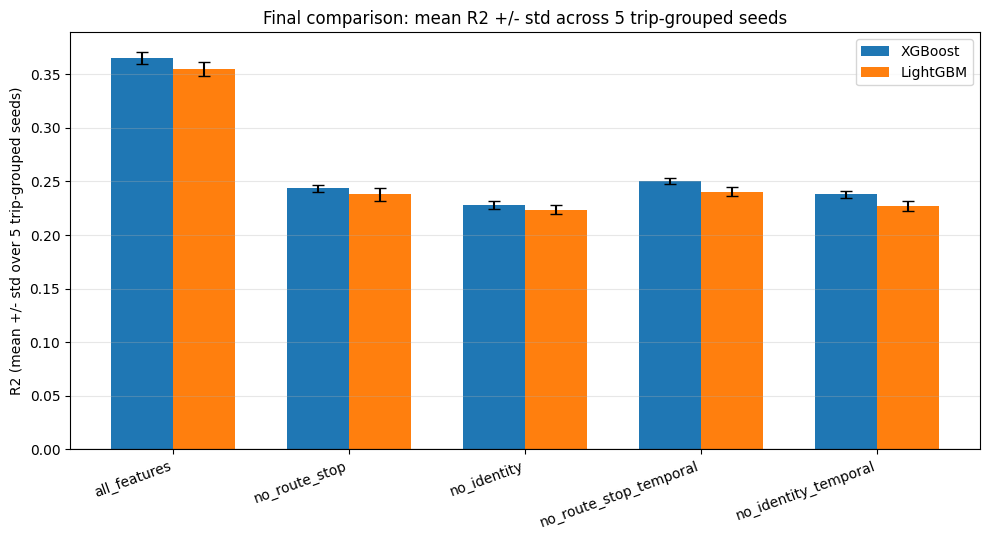

Saved: final_comparison_r2.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 5.5))
config_labels = FINAL_CONFIGS
xpos = np.arange(len(config_labels))
w = 0.35

for i, model in enumerate(FINAL_MODELS):
    sub = final_table[final_table["model"] == model].set_index("feature_set").reindex(config_labels)
    ax.bar(xpos + (i - 0.5) * w, sub["mean_R2"], width=w, yerr=sub["std_R2"],
           capsize=4, label=model)

ax.set_xticks(xpos)
ax.set_xticklabels(config_labels, rotation=20, ha="right")
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("R2 (mean +/- std over 5 trip-grouped seeds)")
ax.set_title("Final comparison: mean R2 +/- std across 5 trip-grouped seeds")
ax.legend(); ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig("../results/experiments/final_comparison_r2.png", dpi=120)
plt.show()
print("Saved: final_comparison_r2.png")